In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import figure
from numpy.ma.core import inner
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [5]:
from pathlib import Path

OUTPUT_DIR = Path("/Users/eraboti/Documents/Forecasting_projects/walmart-recruiting-store-sales-forecasting/tableau_exports")
OUTPUT_DIR.mkdir(exist_ok=True)

print(OUTPUT_DIR.resolve())

/Users/eraboti/Documents/Forecasting_projects/walmart-recruiting-store-sales-forecasting/tableau_exports


In [6]:
import os
for dirname, _, filenames in os.walk('/Users/eraboti/Documents/Forecasting_projects/walmart-recruiting-store-sales-forecasting'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
# Load datasets
train = pd.read_csv("/Users/eraboti/Documents/Forecasting_projects/walmart-recruiting-store-sales-forecasting/train.csv.zip")
test = pd.read_csv("/Users/eraboti/Documents/Forecasting_projects/walmart-recruiting-store-sales-forecasting/test.csv.zip")
features = pd.read_csv("/Users/eraboti/Documents/Forecasting_projects/walmart-recruiting-store-sales-forecasting/features.csv.zip")
stores = pd.read_csv("/Users/eraboti/Documents/Forecasting_projects/walmart-recruiting-store-sales-forecasting/stores.csv")
sample_submission = pd.read_csv('/Users/eraboti/Documents/Forecasting_projects/walmart-recruiting-store-sales-forecasting/sampleSubmission.csv.zip')

/Users/eraboti/Documents/Forecasting_projects/walmart-recruiting-store-sales-forecasting/features.csv.zip
/Users/eraboti/Documents/Forecasting_projects/walmart-recruiting-store-sales-forecasting/.DS_Store
/Users/eraboti/Documents/Forecasting_projects/walmart-recruiting-store-sales-forecasting/sampleSubmission.csv.zip
/Users/eraboti/Documents/Forecasting_projects/walmart-recruiting-store-sales-forecasting/features.csv
/Users/eraboti/Documents/Forecasting_projects/walmart-recruiting-store-sales-forecasting/test.csv.zip
/Users/eraboti/Documents/Forecasting_projects/walmart-recruiting-store-sales-forecasting/train.csv.zip
/Users/eraboti/Documents/Forecasting_projects/walmart-recruiting-store-sales-forecasting/stores.csv


In [7]:
print("train's shape:", train.shape)
print(train.columns)
print(train.head())
print("test's shape:", test.shape)
print(test.columns)
print(test.head())
print("feature's shape:", features.shape)
print(features.head())
print(features.columns)

print("store's shape:",stores.shape)
print(stores.columns)
print(stores.head())
print(sample_submission.shape)
print(sample_submission.head())
print(sample_submission.columns)

train's shape: (421570, 5)
Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday'], dtype='object')
   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False
3      1     1  2010-02-26      19403.54      False
4      1     1  2010-03-05      21827.90      False
test's shape: (115064, 4)
Index(['Store', 'Dept', 'Date', 'IsHoliday'], dtype='object')
   Store  Dept        Date  IsHoliday
0      1     1  2012-11-02      False
1      1     1  2012-11-09      False
2      1     1  2012-11-16      False
3      1     1  2012-11-23       True
4      1     1  2012-11-30      False
feature's shape: (8190, 12)
   Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0      1  2010-02-05        42.31       2.572        NaN        NaN   
1      1  2010-02-12        38.51       2.548        NaN        NaN   
2      1  2010-02-19      

In [8]:
print("Missing values before:")
print(features.isnull().sum()[features.isnull().sum() > 0])
print(features.isnull().sum())
print("Missing values percentage:")
missing_pct = features.isnull().mean() * 100
print(missing_pct.sort_values(ascending=False))

Missing values before:
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
dtype: int64
Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64
Missing values percentage:
MarkDown2       64.334554
MarkDown4       57.704518
MarkDown3       55.885226
MarkDown1       50.769231
MarkDown5       50.549451
CPI              7.142857
Unemployment     7.142857
Store            0.000000
Date             0.000000
Temperature      0.000000
Fuel_Price       0.000000
IsHoliday        0.000000
dtype: float64


In [9]:
markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']
features[markdown_cols] = features[markdown_cols].fillna(0)
features['CPI']= features['CPI'].fillna(features['CPI'].median())
features['Unemployment'] = features['Unemployment'].fillna((features['Unemployment'].median()))
#df = train.merge
df = train.merge(stores, on="Store")
df = df.merge(features, on =["Store", "Date", "IsHoliday"])
print(type(df["Date"].iloc[0]))
df["Date"] = pd.to_datetime(df["Date"])
print("print the dtype of datatime of data:", df["Date"].dtype)
df= df.set_index("Date")
print(df.shape)
print(df.head())

rows = df.shape[0]
columns = df.shape[1]
#
print("Total rows:", rows)
print("Total columns:", columns)
missing = df.isnull().sum()
print("missing values:", missing[missing >0])

<class 'str'>
print the dtype of datatime of data: datetime64[ns]
(421570, 15)
            Store  Dept  Weekly_Sales  IsHoliday Type    Size  Temperature  \
Date                                                                         
2010-02-05      1     1      24924.50      False    A  151315        42.31   
2010-02-12      1     1      46039.49       True    A  151315        38.51   
2010-02-19      1     1      41595.55      False    A  151315        39.93   
2010-02-26      1     1      19403.54      False    A  151315        46.63   
2010-03-05      1     1      21827.90      False    A  151315        46.50   

            Fuel_Price  MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5  \
Date                                                                            
2010-02-05       2.572        0.0        0.0        0.0        0.0        0.0   
2010-02-12       2.548        0.0        0.0        0.0        0.0        0.0   
2010-02-19       2.514        0.0        0.0      

In [10]:
markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']
features[markdown_cols] = features[markdown_cols].fillna(0)
features['CPI']= features['CPI'].fillna(features['CPI'].median())
features['Unemployment'] = features['Unemployment'].fillna((features['Unemployment'].median()))

In [11]:
feature_store = features.merge(stores, on="Store")

feature_store["Date"] = pd.to_datetime(feature_store["Date"])
train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])

feature_store["Year"] = feature_store["Date"].dt.year
feature_store["Month"] = feature_store["Date"].dt.month
feature_store["Week"] = feature_store["Date"].dt.isocalendar().week.astype(int)
feature_store["Day"] = feature_store["Date"].dt.day

train_df = train.merge(
    feature_store,
    how="inner",
    on=["Store", "Date", "IsHoliday"]
)

test_df = test.merge(
    feature_store,
    how="inner",
    on=["Store", "Date", "IsHoliday"]
)



In [12]:
train_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Week,Day
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,2010,2,5,5
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315,2010,2,6,12
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315,2010,2,7,19
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315,2010,2,8,26
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,2010,3,9,5


In [13]:

test_df.head()

,Store,Dept,Date,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Week,Day
0,1,1,2012-11-02,False,55.32,3.386,6766.44,5147.70,50.82,3639.90,2737.42,223.462779,6.573,A,151315,2012,11,44,2
1,1,1,2012-11-09,False,61.24,3.314,11421.32,3370.89,40.28,4646.79,6154.16,223.481307,6.573,A,151315,2012,11,45,9
2,1,1,2012-11-16,False,52.92,3.252,9696.28,292.10,103.78,1133.15,6612.69,223.512911,6.573,A,151315,2012,11,46,16
3,1,1,2012-11-23,True,56.23,3.211,883.59,4.17,74910.32,209.91,303.32,223.561947,6.573,A,151315,2012,11,47,23
4,1,1,2012-11-30,False,52.34,3.207,2460.03,0.00,3838.35,150.57,6966.34,223.610984,6.573,A,151315,2012,11,48,30


In [14]:
train_df.describe().T.style

,count,mean,min,25%,50%,75%,max,std
Store,421570.000000,22.200546,1.000000,11.000000,22.000000,33.000000,45.000000,12.785297
Dept,421570.000000,44.260317,1.000000,18.000000,37.000000,74.000000,99.000000,30.492054
Date,421570,2011-06-18 08:30:31.963375104,2010-02-05 00:00:00,2010-10-08 00:00:00,2011-06-17 00:00:00,2012-02-24 00:00:00,2012-10-26 00:00:00,nan
Weekly_Sales,421570.000000,15981.258123,-4988.940000,2079.650000,7612.030000,20205.852500,693099.360000,22711.183519
Temperature,421570.000000,60.090059,-2.060000,46.680000,62.090000,74.280000,100.140000,18.447931
Fuel_Price,421570.000000,3.361027,2.472000,2.933000,3.452000,3.738000,4.468000,0.458515
MarkDown1,421570.000000,2590.074819,0.000000,0.000000,0.000000,2809.050000,88646.760000,6052.385934
MarkDown2,421570.000000,879.974298,-265.760000,0.000000,0.000000,2.200000,104519.540000,5084.538801
MarkDown3,421570.000000,468.087665,-29.100000,0.000000,0.000000,4.540000,141630.610000,5528.873453
MarkDown4,421570.000000,1083.132268,0.000000,0.000000,0.000000,425.290000,67474.850000,3894.529945


In [15]:
train_df.isna().sum()[train_df.isna().sum() > 0]
test_df.isna().sum()[test_df.isna().sum() > 0]

Series([], dtype: int64)

In [16]:
df_week = train_df.groupby("Week")["Weekly_Sales"].sum()
df_week.head()
# plt.figure(15,5)
# plt.plot(df_week.index, df_week.values)
# plt.title("Sales over years every week")
# plt.xlabel("Week")
# plt.ylabel("Sales per week")
# plt.xticks(range(1, 53, 2))
# plt.grid(True, alpha=0.3)
# plt.show()

Week
1    8.773121e+07
2    8.269676e+07
3    8.273564e+07
4    7.943483e+07
5    1.419895e+08
Name: Weekly_Sales, dtype: float64

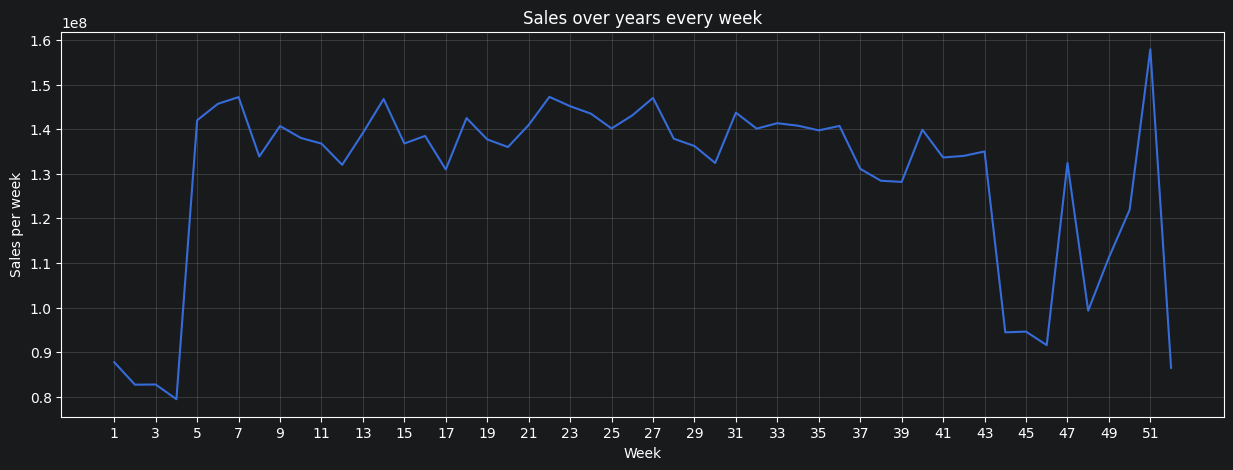

In [17]:
plt.figure(figsize=(15,5))
plt.plot(df_week.index, df_week.values)
plt.title("Sales over years every week")
plt.xlabel("Week")
plt.ylabel("Sales per week")
plt.xticks(range(1, 53, 2))
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
df_mrkd = train_df.groupby("Week")[markdown_cols].sum()
df_mrkd.head()

,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
Week,,,,,
1,1.499397e+07,67007392.71,353486.72,3078155.61,15506769.87
2,1.019858e+07,29235314.34,218513.27,1565390.83,11416226.10
3,7.210967e+06,9824350.22,214079.04,1942054.54,8410008.53
4,4.418107e+06,5170160.65,213215.80,296603.35,7927497.89
5,1.140734e+08,8936033.33,448553.25,90821661.61,18580144.27


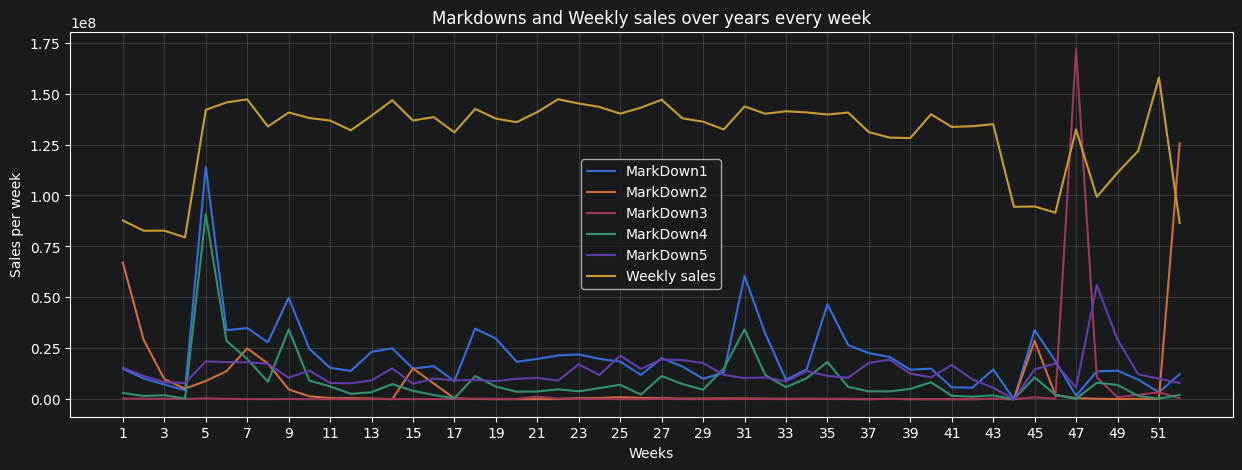

In [19]:
plt.figure(figsize=(15,5))

for col in df_mrkd.columns:
    plt.plot(df_week.index, df_mrkd[col], label=col)
plt.plot(df_week.index, df_week.values, label="Weekly sales")
plt.title("Markdowns and Weekly sales over years every week")
plt.xlabel("Weeks")
plt.ylabel("Sales per week")
plt.xticks(range(1, 53, 2))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [20]:
print(train_df.index)
print(train_df["Date"].head())

RangeIndex(start=0, stop=421570, step=1)
0   2010-02-05
1   2010-02-12
2   2010-02-19
3   2010-02-26
4   2010-03-05
Name: Date, dtype: datetime64[ns]


In [21]:
weekly_sales_year = train_df.groupby(["Year", "Week"], as_index=False)["Weekly_Sales"].agg(["mean", "median"])
weekly_sales_year.head()

,Year,Week,mean,median
0,2010,5,16836.121997,7904.690
1,2010,6,16352.056032,8365.095
2,2010,7,16216.658979,8411.250
3,2010,8,14899.549688,7235.800
4,2010,9,15921.015727,7717.975


In [22]:
weekly_sales_year = train_df.groupby(["Year", "Week"], as_index=False).agg({"Weekly_Sales": ['mean', 'median']})

weekly_sales_year.head()

Year Week  Weekly_Sales          
                      mean    median
0  2010    5  16836.121997  7904.690
1  2010    6  16352.056032  8365.095
2  2010    7  16216.658979  8411.250
3  2010    8  14899.549688  7235.800
4  2010    9  15921.015727  7717.975

In [23]:
print(np.unique(weekly_sales_year['Year']))

[2010 2011 2012]


In [24]:
weekly_sales_2010 = train_df.loc[train_df["Year"] == 2010].groupby("Week")["Weekly_Sales"].agg(["mean", "median"])
weekly_sales_2010.head()

,mean,median
Week,,
5,16836.121997,7904.690
6,16352.056032,8365.095
7,16216.658979,8411.250
8,14899.549688,7235.800
9,15921.015727,7717.975


In [25]:
weekly_sales_2011 = train_df.loc[train_df["Year"]==2011].groupby("Week")["Weekly_Sales"].agg(["mean", "median"])
weekly_sales_2011.head()

,mean,median
Week,,
1,14599.244973,6384.990
2,13891.283484,5961.710
3,13932.367385,6139.315
4,13566.239462,6227.980
5,15773.448776,7312.115


In [26]:
weekly_sales_2012 = train_df.loc[train_df["Year"]==2012].groupby("Week")["Weekly_Sales"].agg(["mean", "median"])
weekly_sales_2012.head()

,mean,median
Week,,
1,15121.231736,6586.37
2,14168.266514,5914.86
3,14221.357405,6146.31
4,13494.232612,5785.84
5,15480.553608,6859.65


In [27]:
weekly_sales_all_years = {
    '2010': weekly_sales_2010['mean'].to_dict(),
    '2011': weekly_sales_2011['mean'].to_dict(),
    '2012': weekly_sales_2012['mean'].to_dict(),
}

In [28]:
weekly_sales_all_df = pd.DataFrame(weekly_sales_all_years)
weekly_sales_all_df.head()

,2010,2011,2012
5,16836.121997,15773.448776,15480.553608
6,16352.056032,16111.706191,16664.247891
7,16216.658979,16541.991212,16693.401051
8,14899.549688,15049.747558,15458.124475
9,15921.015727,15882.557045,15672.586946


In [29]:
print(weekly_sales_all_df.head(10))
print(weekly_sales_all_df.tail(10))
print(weekly_sales_all_df.index)
print(weekly_sales_all_df.isna().sum())

            2010          2011          2012
5   16836.121997  15773.448776  15480.553608
6   16352.056032  16111.706191  16664.247891
7   16216.658979  16541.991212  16693.401051
8   14899.549688  15049.747558  15458.124475
9   15921.015727  15882.557045  15672.586946
10  15546.850545  15056.450540  15965.182956
11  15286.773578  15216.115961  15823.719615
12  14975.894486  14573.827050  15195.472627
13  17098.620298  14726.869261  15289.720371
14  16050.589780  15634.571312  17935.741157
            2010          2011          2012
47  22403.336705  22043.563476           NaN
48  16924.051502  16496.511854           NaN
49  18882.893619  18458.853056           NaN
50  20892.463619  19942.149333           NaN
51  27378.692693  25437.146122           NaN
52  13738.538566  15332.154858           NaN
1            NaN  14599.244973  15121.231736
2            NaN  13891.283484  14168.266514
3            NaN  13932.367385  14221.357405
4            NaN  13566.239462  13494.232612
Index([ 5,

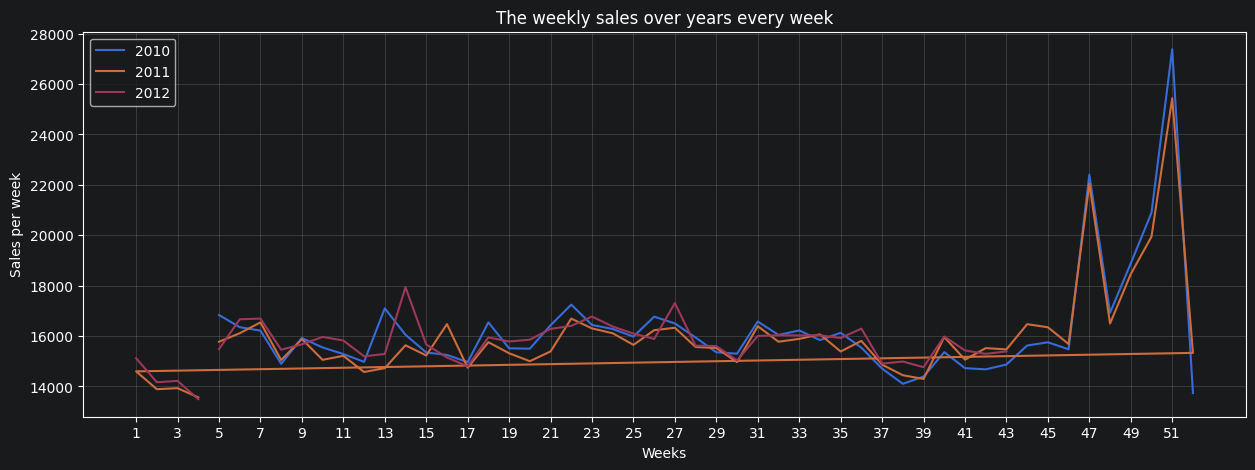

In [30]:
years_columns = ['2010', '2011', '2012']
plt.figure(figsize=(15,5))
for col in years_columns:
    plt.plot(weekly_sales_all_df.index,weekly_sales_all_df[col], label=col)
plt.title("The weekly sales over years every week")
plt.xlabel("Weeks")
plt.ylabel("Sales per week")
plt.xticks(range(1, 53, 2))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

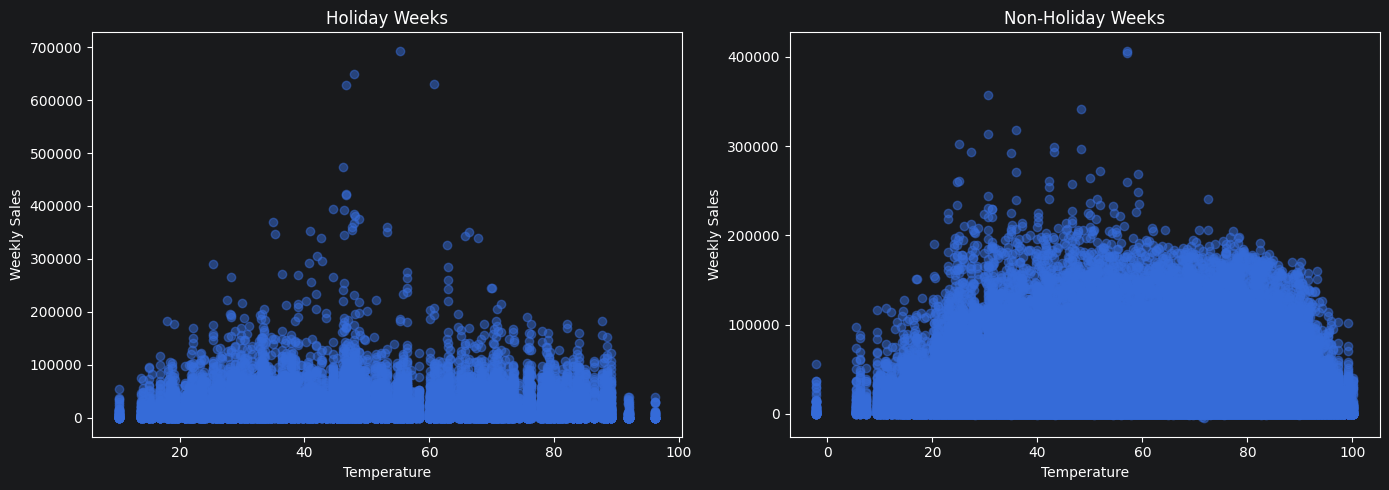

In [31]:
holiday = train_df[train_df["IsHoliday"] == True]
nonholiday = train_df[train_df["IsHoliday"] == False]

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Holiday
axes[0].scatter(
    holiday["Temperature"],
    holiday["Weekly_Sales"],
    alpha=0.5
)

axes[0].set_title("Holiday Weeks")
axes[0].set_xlabel("Temperature")
axes[0].set_ylabel("Weekly Sales")

# Non-Holiday
axes[1].scatter(
    nonholiday["Temperature"],
    nonholiday["Weekly_Sales"],
    alpha=0.5
)

axes[1].set_title("Non-Holiday Weeks")
axes[1].set_xlabel("Temperature")
axes[1].set_ylabel("Weekly Sales")

plt.tight_layout()
plt.show()

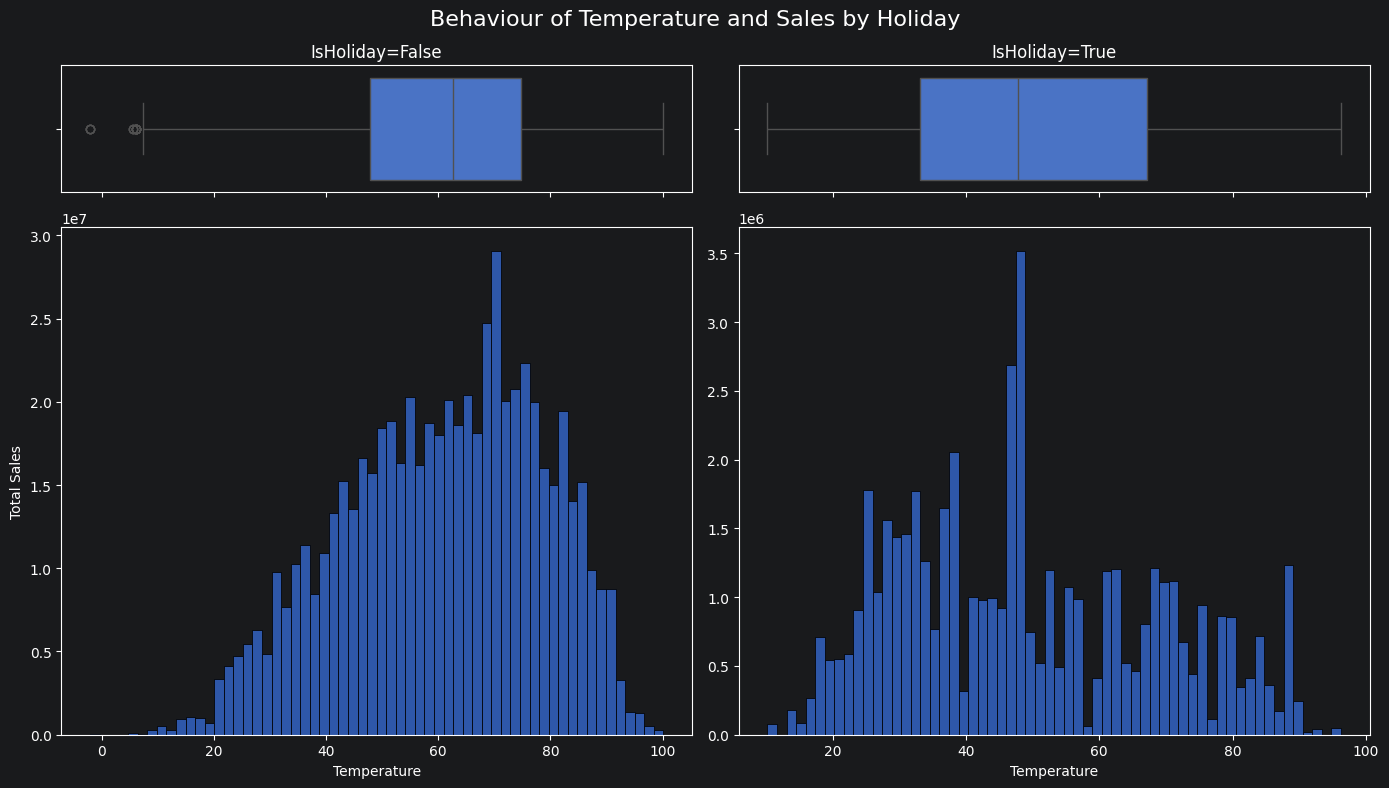

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

train_plt = train_df.sample(frac=0.1, random_state=42)

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 8),
    gridspec_kw={"height_ratios": [1, 4]},
    sharex="col"
)

# Split data
non_holiday = train_plt[train_plt["IsHoliday"] == False]
holiday = train_plt[train_plt["IsHoliday"] == True]

# Boxplots
sns.boxplot(data=non_holiday, x="Temperature", ax=axes[0, 0])
axes[0, 0].set_title("IsHoliday=False")
axes[0, 0].set_xlabel("")

sns.boxplot(data=holiday, x="Temperature", ax=axes[0, 1])
axes[0, 1].set_title("IsHoliday=True")
axes[0, 1].set_xlabel("")

# Histograms weighted by sales
sns.histplot(
    data=non_holiday,
    x="Temperature",
    weights="Weekly_Sales",
    bins=60,
    ax=axes[1, 0]
)
axes[1, 0].set_xlabel("Temperature")
axes[1, 0].set_ylabel("Total Sales")

sns.histplot(
    data=holiday,
    x="Temperature",
    weights="Weekly_Sales",
    bins=60,
    ax=axes[1, 1]
)
axes[1, 1].set_xlabel("Temperature")
axes[1, 1].set_ylabel("")

fig.suptitle("Behaviour of Temperature and Sales by Holiday", fontsize=16)
plt.tight_layout()
plt.show()

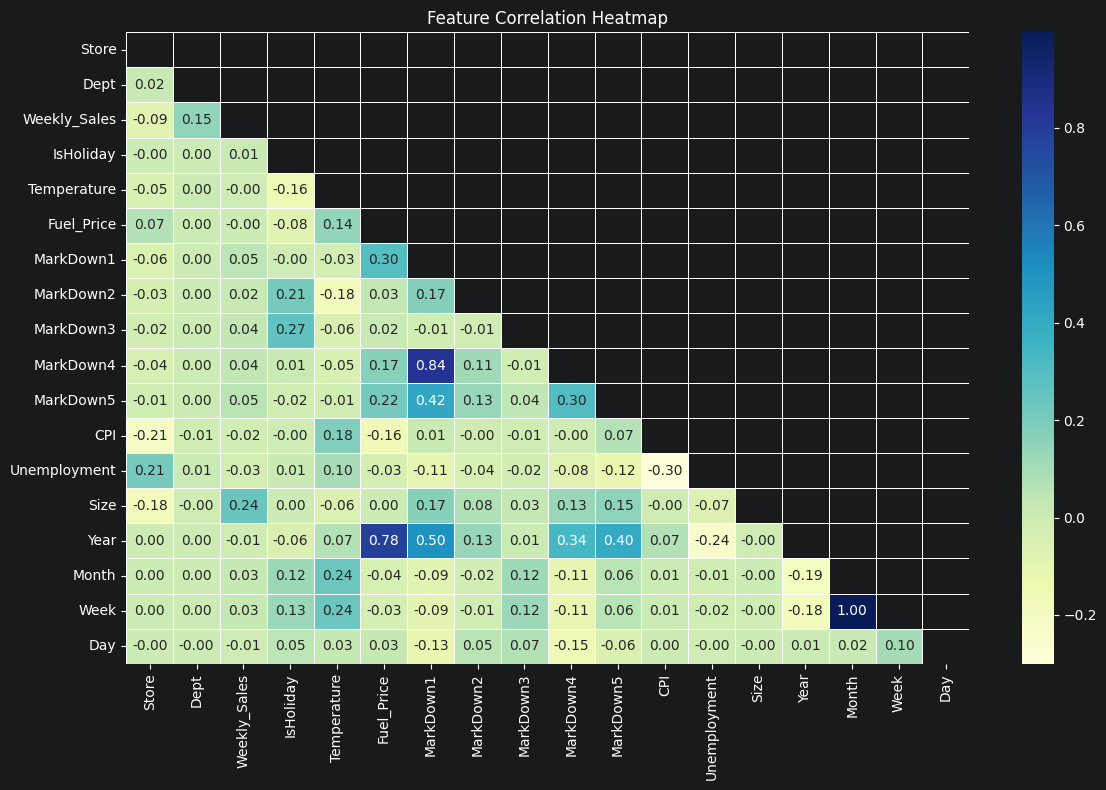

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

numeric_train = train_df.select_dtypes(include=["number", "bool"])

corr = numeric_train.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

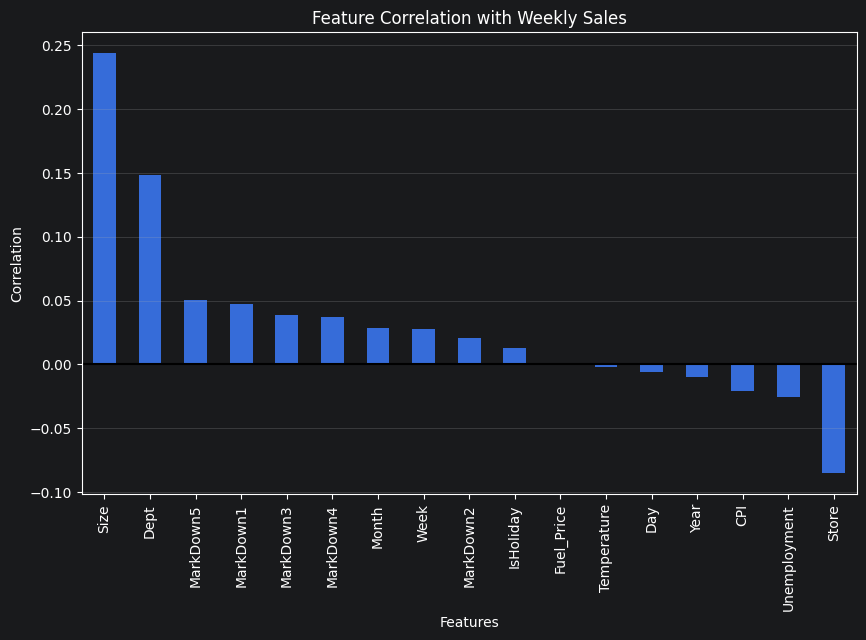

In [34]:
corr = train_df.select_dtypes(include=["number", "bool"]).corr()

sales_corr = (
    corr["Weekly_Sales"]
    .drop("Weekly_Sales")
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sales_corr.plot(
    kind="bar"
)

plt.title("Feature Correlation with Weekly Sales")
plt.xlabel("Features")
plt.ylabel("Correlation")
plt.axhline(0, color="black")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [35]:
data_train = train_df.copy()
data_test = test_df.copy()

In [36]:
sales_tableau = data_train.copy()

sales_tableau.to_csv(
    OUTPUT_DIR / "/Users/eraboti/Documents/Forecasting_projects/walmart-recruiting-store-sales-forecasting/tableau_exports/sales_data.csv",
    index=False
)

print("Saved sales_data.csv")
sales_tableau.head()

Saved sales_data.csv


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Week,Day
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,2010,2,5,5
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315,2010,2,6,12
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315,2010,2,7,19
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315,2010,2,8,26
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,2010,3,9,5


In [37]:
data_train['SuperBowlWeek'] = (data_train['Week'] == 6).astype(int)
data_train['LaborDay'] = (data_train['Week'] == 36).astype(int)
data_train['Thanksgiving'] = (data_train['Week'] == 47).astype(int)
data_train['Christmas'] = (data_train['Week'] == 52).astype(int)

data_test['SuperBowlWeek'] = (data_test['Week'] == 6).astype(int)
data_test['LaborDay'] = (data_test['Week'] == 36).astype(int)
data_test['Thanksgiving'] = (data_test['Week'] == 47).astype(int)
data_test['Christmas'] = (data_test['Week'] == 52).astype(int)

In [38]:
data_train['MarkdownsSum'] = data_train[markdown_cols].sum(axis=1)
data_test['MarkdownsSum'] = data_test[markdown_cols].sum(axis=1)

In [39]:
data_train['Type'] = data_train['Type'].map({
    'A':1,
    'B':2,
    'C':3
})

data_test['Type'] = data_test['Type'].map({
    'A':1,
    'B':2,
    'C':3
})
df_train_df_df = pd.DataFrame(data_train)
df_test_df_df = pd.DataFrame(data_test)
df_train_df_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Size,Year,Month,Week,Day,SuperBowlWeek,LaborDay,Thanksgiving,Christmas,MarkdownsSum
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,...,151315,2010,2,5,5,0,0,0,0,0.0
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,...,151315,2010,2,6,12,1,0,0,0,0.0
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,...,151315,2010,2,7,19,0,0,0,0,0.0
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,...,151315,2010,2,8,26,0,0,0,0,0.0
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,...,151315,2010,3,9,5,0,0,0,0,0.0


In [40]:
data_train['IsHoliday'] = data_train['IsHoliday'].astype(int)
data_test['IsHoliday'] = data_test['IsHoliday'].astype(int)

In [41]:
print(data_train.shape)
data_train.head()
data_train.dtypes

(421570, 25)


Store                     int64
Dept                      int64
Date             datetime64[ns]
Weekly_Sales            float64
IsHoliday                 int64
Temperature             float64
Fuel_Price              float64
MarkDown1               float64
MarkDown2               float64
MarkDown3               float64
MarkDown4               float64
MarkDown5               float64
CPI                     float64
Unemployment            float64
Type                      int64
Size                      int64
Year                      int32
Month                     int32
Week                      int64
Day                       int32
SuperBowlWeek             int64
LaborDay                  int64
Thanksgiving              int64
Christmas                 int64
MarkdownsSum            float64
dtype: object

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor


# Features and target
feature_cols = [col for col in data_train.columns if col not in ["Date", "Weekly_Sales"]]

X = data_train[feature_cols].copy()
y = data_train["Weekly_Sales"].copy()

# Use sample to make it faster
sample_idx = data_train.sample(frac=0.25, random_state=42).index
X_sample = X.loc[sample_idx]
y_sample = y.loc[sample_idx]

# Temporary split for feature importance
X_train, X_valid, y_train, y_valid = train_test_split(
    X_sample,
    y_sample,
    test_size=0.15,
    random_state=42
)

model = XGBRegressor(
    random_state=42,
    objective="reg:squarederror",
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1
)

model.fit(X_train, y_train)

result = permutation_importance(
    model,
    X_valid,
    y_valid,
    n_repeats=5,
    random_state=42,
    scoring="neg_root_mean_squared_error"
)

importance_df = pd.DataFrame({
    "Feature": X_valid.columns,
    "Importance": result.importances_mean
}).sort_values("Importance", ascending=False)

importance_df.head()

,Feature,Importance
1,Dept,21993.377438
13,Size,9988.870398
0,Store,3169.496075
10,CPI,1597.396294
16,Week,1401.926677


In [47]:
importance_df.to_csv(
    OUTPUT_DIR / "/Users/eraboti/Documents/Forecasting_projects/walmart-recruiting-store-sales-forecasting/tableau_exports/feature_importance.csv",
    index=False
)

print("Saved feature_importance.csv")
importance_df.head()

Saved feature_importance.csv


,Feature,Importance
1,Dept,21993.377438
13,Size,9988.870398
0,Store,3169.496075
10,CPI,1597.396294
16,Week,1401.926677


In [43]:
print(data_train.columns.tolist())
print(len(data_train.columns.tolist()))

['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size', 'Year', 'Month', 'Week', 'Day', 'SuperBowlWeek', 'LaborDay', 'Thanksgiving', 'Christmas', 'MarkdownsSum']
25


In [44]:
data_train["Days_to_Thanksgiving"] = (
    pd.to_datetime(data_train["Year"].astype(str) + "-11-24")
    - data_train["Date"]
).dt.days

data_train["Days_to_Christmas"] = (
    pd.to_datetime(data_train["Year"].astype(str) + "-12-24")
    - data_train["Date"]
).dt.days

In [45]:
data_test["Days_to_Thanksgiving"] = (
    pd.to_datetime(data_train["Year"].astype(str) + "-11-24")
    - data_train["Date"]
).dt.days

data_test["Days_to_Christmas"] = (
    pd.to_datetime(data_train["Year"].astype(str) + "-12-24")
    - data_train["Date"]
).dt.days

In [49]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor


def WMAE(dataset, real, predicted):
    weights = dataset["IsHoliday"].apply(lambda x: 5 if x == 1 else 1)
    return np.round(np.sum(weights * abs(real - predicted)) / np.sum(weights), 2)


feature_cols = [
    "Store", "Dept", "IsHoliday", "Size", "Week", "Type", "Year", "Day",
    "Month", "Temperature", "Fuel_Price", "CPI", "Unemployment",
    "SuperBowlWeek", "LaborDay", "Thanksgiving", "Christmas",
    "MarkdownsSum"
]

X = data_train[feature_cols].copy()
y = data_train["Weekly_Sales"].copy()

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.1, random_state=42
)

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=60,
        max_depth=25,
        min_samples_split=3,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ),

    "CatBoost": CatBoostRegressor(
        iterations=300,
        depth=8,
        learning_rate=0.05,
        loss_function="RMSE",
        random_seed=42,
        verbose=False
    )
}

results = []
prediction_tables = []
for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_valid)
    pred_df = X_valid.copy()
    pred_df = X_valid.copy()

    pred_df["Date"] = data_train.loc[X_valid.index, "Date"].values
    pred_df["Actual_Sales"] = y_valid.values
    pred_df["Predicted_Sales"] = y_pred
    pred_df["Model"] = name

    prediction_tables.append(pred_df)


    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_valid, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_valid, y_pred)),
        "R2": r2_score(y_valid, y_pred),
        "WMAE": WMAE(data_train.loc[X_valid.index], y_valid, y_pred)
    })

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)

results_df


Training Random Forest...
Training Extra Trees...
Training XGBoost...
Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003990 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1548
[LightGBM] [Info] Number of data points in the train set: 379413, number of used features: 18
[LightGBM] [Info] Start training from score 15987.888448
Training CatBoost...


,Model,MAE,RMSE,R2,WMAE
0,Extra Trees,1243.206366,2882.008667,0.983625,1392.82
1,Random Forest,1265.902406,3060.803473,0.981530,1410.39
2,XGBoost,2495.922728,4460.414091,0.960776,2588.56
3,LightGBM,2983.907909,4910.926771,0.952453,3091.64
4,CatBoost,4688.414083,7821.456206,0.879393,4819.17


In [50]:
predictions_df = pd.concat(
    prediction_tables,
    ignore_index=True
)

predictions_df.to_csv(
    OUTPUT_DIR / "/Users/eraboti/Documents/Forecasting_projects/walmart-recruiting-store-sales-forecasting/tableau_exports/predictions.csv",
    index=False
)

print("Saved predictions.csv")
predictions_df.head()

Saved predictions.csv


,Store,Dept,IsHoliday,Size,Week,Type,Year,Day,Month,Temperature,...,Unemployment,SuperBowlWeek,LaborDay,Thanksgiving,Christmas,MarkdownsSum,Date,Actual_Sales,Predicted_Sales,Model
0,28,40,0,206302,1,1,2012,6,1,50.43,...,12.187,0,0,0,0,30778.89,2012-01-06,50932.42,50644.146486,Random Forest
1,18,93,0,120653,10,2,2012,9,3,38.10,...,8.075,0,0,0,0,11988.29,2012-03-09,3196.12,3267.245087,Random Forest
2,38,4,0,39690,21,3,2011,27,5,76.67,...,13.736,0,0,0,0,0.00,2011-05-27,10125.03,10448.268111,Random Forest
3,29,33,0,93638,10,2,2010,12,3,43.43,...,10.064,0,0,0,0,0.00,2010-03-12,3311.26,3898.935396,Random Forest
4,13,52,0,219622,43,1,2010,29,10,45.12,...,7.795,0,0,0,0,0.00,2010-10-29,6335.65,5458.768136,Random Forest


In [51]:
results_df.to_csv(
    OUTPUT_DIR / "/Users/eraboti/Documents/Forecasting_projects/walmart-recruiting-store-sales-forecasting/tableau_exports/metrics.csv",
    index=False
)

print("Saved metrics.csv")
results_df

Saved metrics.csv


,Model,MAE,RMSE,R2,WMAE
0,Extra Trees,1243.206366,2882.008667,0.983625,1392.82
1,Random Forest,1265.902406,3060.803473,0.981530,1410.39
2,XGBoost,2495.922728,4460.414091,0.960776,2588.56
3,LightGBM,2983.907909,4910.926771,0.952453,3091.64
4,CatBoost,4688.414083,7821.456206,0.879393,4819.17


The time series split

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor


# Features and target
feature_cols = [col for col in data_train.columns if col not in ["Date", "Weekly_Sales"]]

X = data_train[feature_cols].copy()
y = data_train["Weekly_Sales"].copy()

# Use sample to make it faster
sample_idx = data_train.sample(frac=0.25, random_state=42).index
X_sample = X.loc[sample_idx]
y_sample = y.loc[sample_idx]

# Temporary split for feature importance
X_train, X_valid, y_train, y_valid = train_test_split(
    X_sample,
    y_sample,
    test_size=0.15,
    random_state=42
)

model = XGBRegressor(
    random_state=42,
    objective="reg:squarederror",
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1
)

model.fit(X_train, y_train)

result = permutation_importance(
    model,
    X_valid,
    y_valid,
    n_repeats=5,
    random_state=42,
    scoring="neg_root_mean_squared_error"
)

importance_df = pd.DataFrame({
    "Feature": X_valid.columns,
    "Importance": result.importances_mean
}).sort_values("Importance", ascending=False)

importance_df.head()